Notebook explaining step by step how we build the `compute_likelihood_map` function.

In [1]:
from retinotopy import *
args = Params()

----------------------------------------------------------------------------------
On date 2024-05-14, Running learning on host Ahsoka with device cpu, pytoch==2.2.2
----------------------------------------------------------------------------------
Welcome on macOS-14.5-x86_64-i386-64bit


In [2]:
resolution = (128, 128)
resolution = (64, 64)
resolution = (32, 32)
size_ratio = 0.06 # how much of the image to use relative to radius
size_ratio = 0.15 # how much of the image to use relative to radius
size_ratio = 0.10 # how much of the image to use relative to radius

## doing the computations

In [3]:
image_name = 'frog' # to debug
image_name = 'green-jungle-trees-plants-hd-1080P-wallpaper'
image_name = 'fluffy-white-clouds'
image_name = 'my_jackson_pollock_painting_by_amau41200-d4vjeut'
image_name = 'fractal'
image_name = 'farm_animals' # to debug
image_name = 'JamesWebbSpaceTelescope'
image_name = 'L3HYK4hkM2gUTjBQbBMVkG' # mars rover
image_name = 'Nanedi_Valles_valley_system_on_Mars_ESA199848'
image_name = 'jwst-carina-nebula'
image_url = f'./imgs/{image_name}.jpg'

full_image = read_image(image_url)/255
three, H, W = full_image.shape

full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()
print(f"{type(full_image) = }, {full_image.dtype = }, {full_image.shape = }")

method = 'valid'
method = 'full'

type(full_image) = <class 'torch.Tensor'>, full_image.dtype = torch.float32, full_image.shape = torch.Size([3, 2085, 3600])


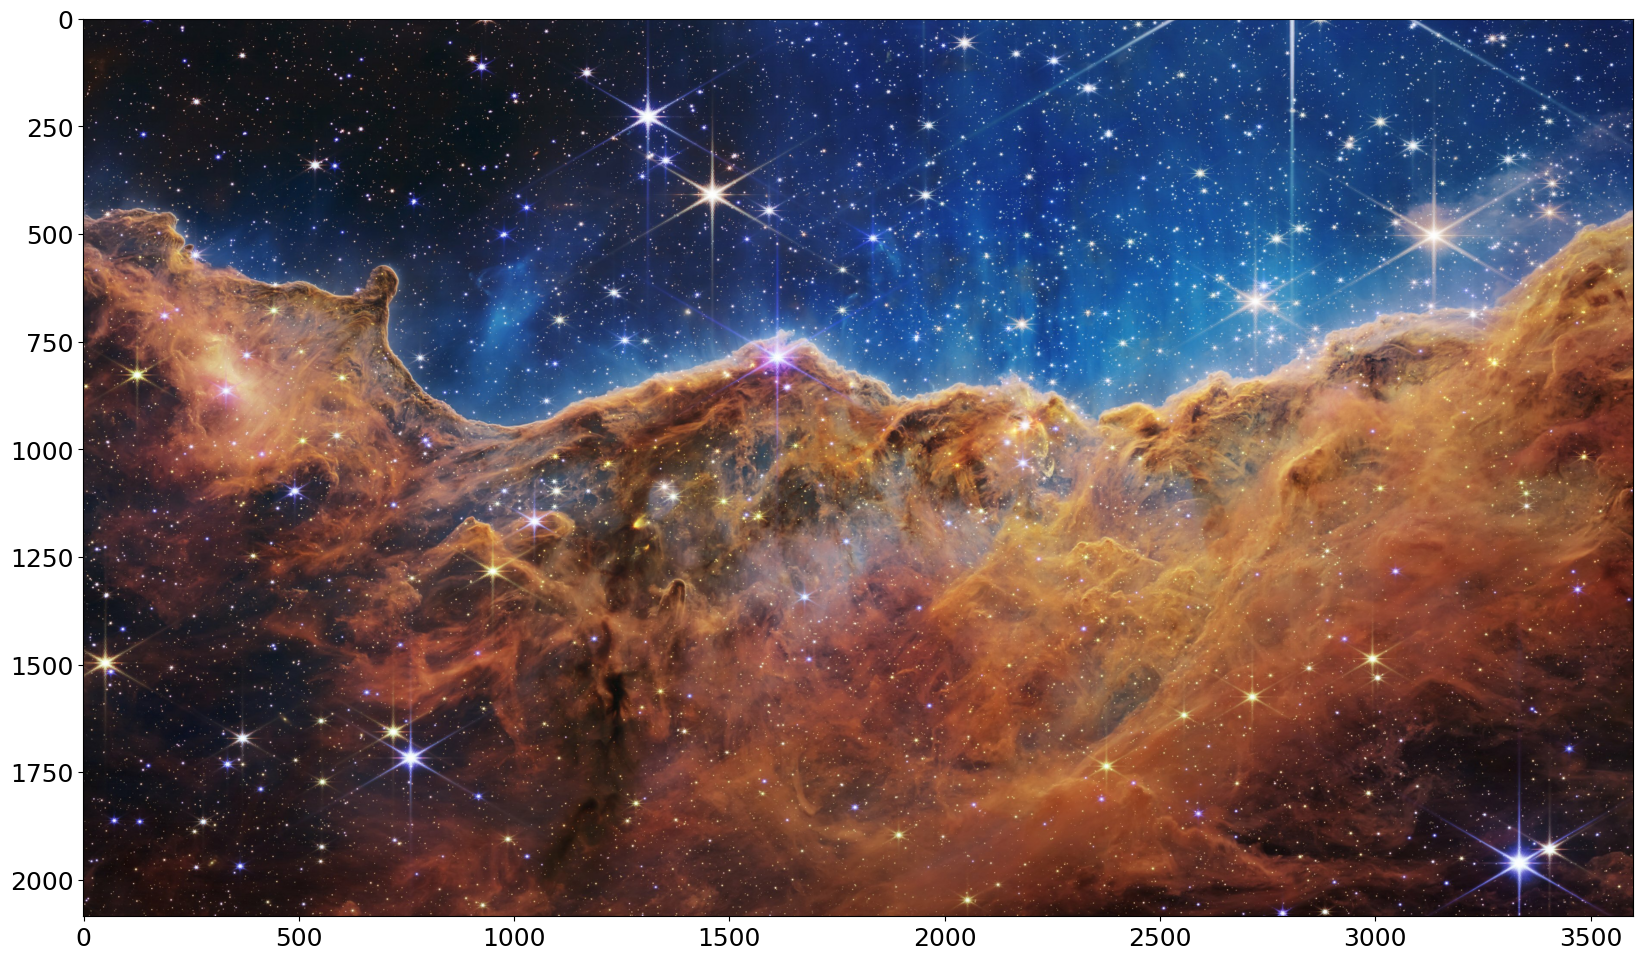

In [4]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
ax.imshow(full_image_np)


In [5]:
N_fixations = np.prod(resolution)
aspect_ratio = full_image.shape[1]/full_image.shape[2]
resolution = (int(np.sqrt(N_fixations*aspect_ratio)),
                int(np.sqrt(N_fixations/aspect_ratio)))
resolution

(24, 42)

In [6]:
pos_H, pos_W, box_size = get_positions(full_image, resolution, size_ratio, method=method)
box_size

208

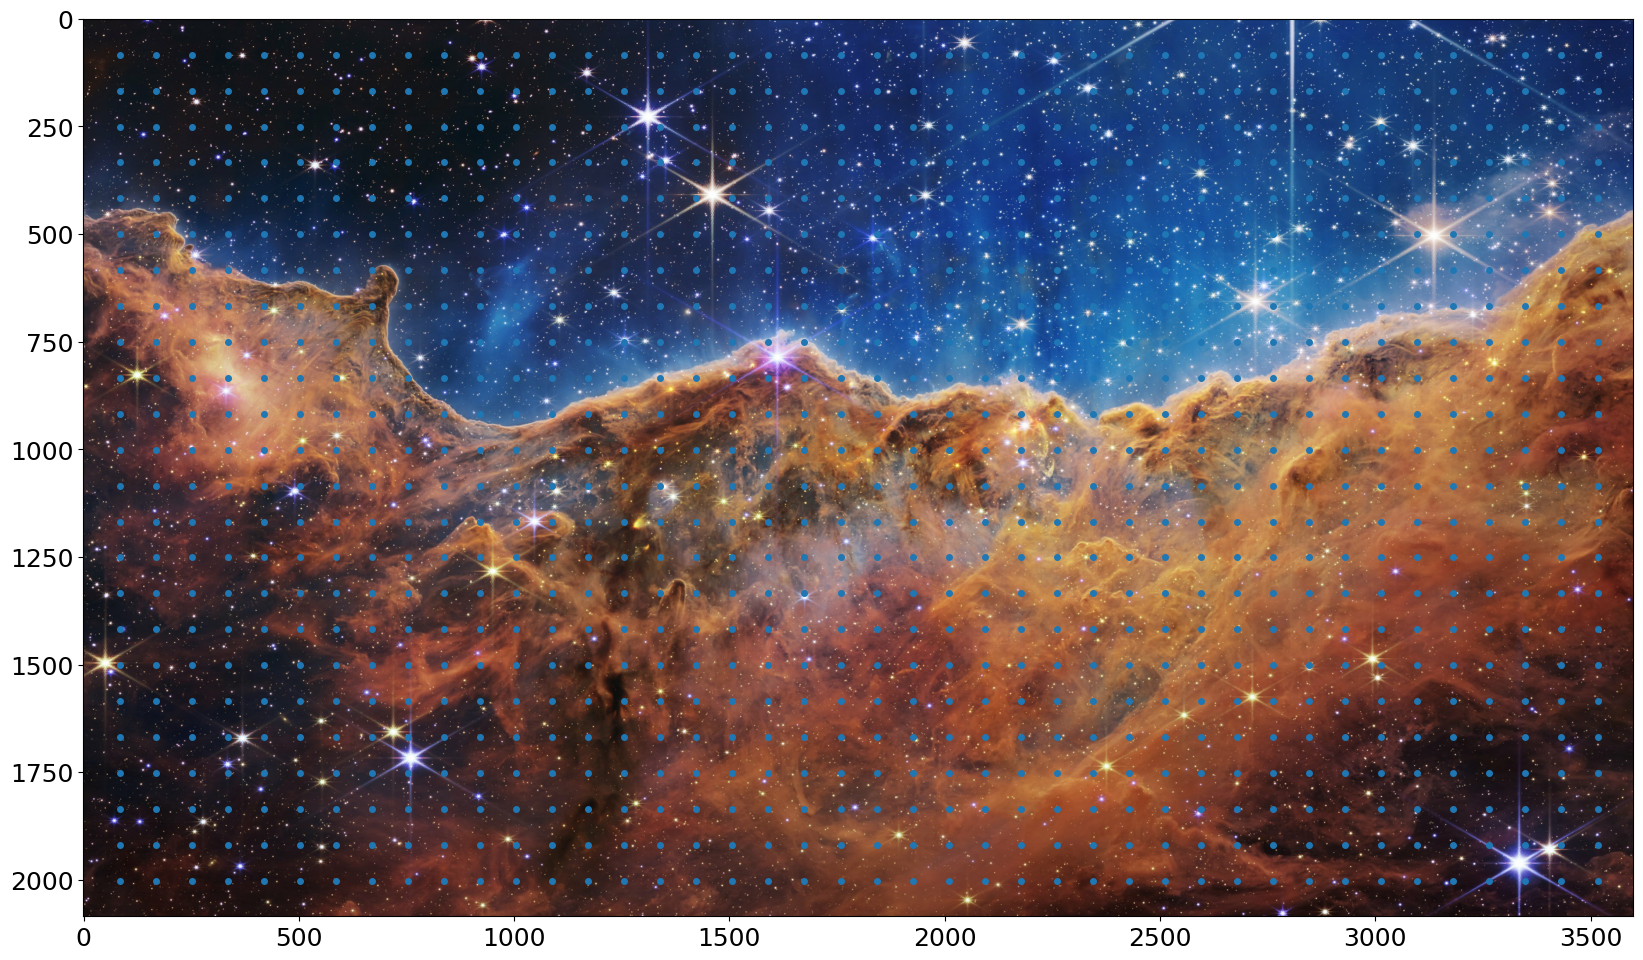

In [7]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
ax.scatter(pos_W.ravel(), pos_H.ravel(), s=16)
# ax.set_yticks([])  
fig.set_facecolor(color='white')

In [8]:
data_set_type = 'focus'
model_name = 'resnet101'
do_polar = True

map_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_map_{image_name}.npy'
if True: # not os.path.isfile(map_filename):

    args.image_size = box_size
    args.do_polar = do_polar

    model_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}.pt'
    print(f"Loading pre-trained resnet {model_filename}")
    model = charge_model(model_name=model_name, model_path=model_filename, 
                         do_circular=args.do_polar).to(device).eval()
    

    pos_H, pos_W, probas = compute_likelihood_map(args, model, full_image, resolution=resolution, size_ratio=size_ratio, method=method)
    np.save(map_filename, probas)
else:
    probas = np.load(map_filename)


Loading pre-trained resnet cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
loading .... cached_data/2024-05-14_focus_resnet101_do_polar=True.pt


FileNotFoundError: [Errno 2] No such file or directory: 'cached_data/2024-05-14_focus_resnet101_do_polar=True.pt'

In [ ]:
%ls -lh {map_filename}

In [ ]:
# %rm -f {map_filename}

In [ ]:
probas.shape

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
ax.hist(probas.flatten(), bins=100, density=True)
# ax.set_xscale('log')
ax.set_yscale('log')

In [ ]:
proba_max = np.max(probas, axis=1)
proba_max.shape

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
ax.imshow(proba_max.reshape((resolution[1], resolution[0])).T, cmap='viridis', vmin=0, vmax=1)

## finding animals

Let's focus on the animals in the image. We will use the following masks to find the animals in the image.

In [ ]:
proba_focus = probas[:, :397]
proba_focus /= np.sum(proba_focus, axis=1)[:, None]
proba_max = np.max(proba_focus, axis=1)
proba_focus.shape, proba_max.shape, np.sum(proba_focus, axis=1)

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
ax.imshow(proba_max.reshape((resolution[1], resolution[0])).T, cmap='viridis', vmin=0, vmax=1)

In [ ]:
for label in np.argmax(proba_focus, axis=1):
    print(label, labels[label])
    break

In [ ]:
proba_focus = probas.copy()
# proba_focus[:, :397] = 0 # remove animals
proba_focus[:, 397:] = 0 # remove other classes than animals
# proba_focus[:, 41] = 0 # shunt whiptail
# proba_focus[:, 1] = 0 # shunt goldfish
# proba_focus[:, 111] = 0 # shunt nematode
# proba_focus[:, 108] = 0 # shunt sea_anemone
# proba_focus[:, 115] = 0 # shunt sea_slug
# proba_focus[:, 116] = 0 # shunt chiton
# proba_focus[:, 51] = 0 # shunt triceratops
# proba_focus[:, 296] = 0 # shunt ice_bear 
# proba_focus[:, 112] = 0 # shunt conch
proba_focus[:, 107] = 0 # shunt jellyfish
# proba_focus[:, 818] = 0 # shunt spotlight
# proba_focus[:, 971] = 0 # shunt bubble
# proba_focus[:, 599] = 0 # shunt honeycomb
proba_focus /= np.sum(proba_focus, axis=1)[:, None]
proba_max = np.max(proba_focus, axis=1)
proba_focus.shape, proba_max.shape#, np.sum(proba_focus, axis=1)

In [ ]:
for label in np.argmax(proba_focus, axis=1):
    print(label, labels[label])
    break

In [ ]:
pos_W.ravel().shape, pos_H.ravel().shape

In [ ]:
proba_max = np.max(proba_focus, axis=1)
idx = np.argmax(proba_focus, axis=1)
idx_bests = np.argsort(-proba_max)
proba_max.shape, idx.shape, idx_bests.shape, idx_bests[:10]

In [ ]:
N_best = 24
for idx_best in idx_bests[:N_best]:
    print(f'{idx_best}\t\t\tP={proba_max[idx_best]:.3f}\t\t\th={pos_H.ravel()[idx_best]:06.1f}\tw={pos_W.ravel()[idx_best]:06.1f}\t\t{labels[idx[idx_best]]} ({idx[idx_best]})')

In [ ]:
cropped_images = torch.empty((N_best, 3, box_size, box_size))

for i_best, idx_best in enumerate(idx_bests[:N_best]):
    label = labels[idx[idx_best]]
    proba_label = proba_max[idx_best]
    h, w = int(pos_H.ravel()[idx_best]), int(pos_W.ravel()[idx_best])
    cropped_image = crop(full_image, h-box_size//2, w-box_size//2, box_size, box_size)
    cropped_images[i_best, ...] = (cropped_image - cropped_image.min())/(cropped_image.max() - cropped_image.min())
imshow(cropped_images, im_mean=0, im_std=1)

In [ ]:
h, w, h-box_size//2, w-box_size//2, box_size, box_size

## doing the figure

In [ ]:
N_best = 5
proba_max = np.max(proba_focus, axis=1)
idx = np.argmax(proba_focus, axis=1)
idx_bests = np.argsort(-proba_max)
idx_bests = idx_bests[:N_best]

In [ ]:
pos_W.ravel()[idx_bests]


In [ ]:
idx_bests_pos = np.argsort(pos_W.ravel()[idx_bests])
idx_bests, idx_bests_pos

In [ ]:
# https://matplotlib.org/stable/gallery/axes_grid1/inset_locator_demo.html
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
extent = (0, W, 0, H)
ax.imshow(full_image_np, origin="upper", extent=extent)
ax.set_xticks([])
ax.set_yticks([])

for i_best, idx_best_pos in enumerate(idx_bests_pos):
    idx_best = idx_bests[idx_best_pos]
    # axins = inset_axes(ax, width="100%", height="100%",
    #                bbox_to_anchor=(i_best/N_best, 1., 1/N_best, 1/N_best),
    #                bbox_transform=ax.transAxes, loc=3)

    label = labels[idx[idx_best]]
    proba_label = proba_max[idx_best]
    h, w = int(pos_H.ravel()[idx_best]), int(pos_W.ravel()[idx_best])
    cropped_image = crop(full_image, h-box_size//2, w-box_size//2, box_size, box_size)

    # axins.imshow(cropped_image.numpy().transpose((1, 2, 0)))
    axins = zoomed_inset_axes(ax, zoom=1./size_ratio/N_best,
                   bbox_to_anchor=(i_best/N_best, 1.02, 1./N_best, 1./N_best),
                   bbox_transform=ax.transAxes)
    
    axins.imshow(full_image_np, origin="upper", extent=extent)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_ylabel(label)
    axins.set_xlim(w-box_size//2, w+box_size//2)
    axins.set_ylim(h-box_size//2, h+box_size//2)
    mark_inset(ax, axins, loc1=1, loc2=3)
fig.set_facecolor(color='white')

In [ ]:
pos_H.shape

In [ ]:
for ext in exts:
    fig.savefig(f'figs/sup-pareidolia.{ext}',  **opts_savefig)